# Imports

In [46]:
## conda env: stereo_visionn
import os
import cv2
import glob
import numpy as np
from rtmlib import draw_skeleton, draw_bbox
from Util.util import *
import time
import json
from IPython.display import display, clear_output

import pyzed.sl as sl
import matplotlib.pyplot as plt

with open('./Util/models.json') as f:
    models = json.load(f)

with open("./Util/properties.json", "r") as json_file:
    gait_analysis_properties = json.load(json_file)

%matplotlib ipympl
# %matplotlib notebook
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# 2D Keypoints

## Model setup

In [ ]:
device = "cuda"  # cpu, cuda, mps
backend = "onnxruntime"  # opencv, onnxruntime, openvino
detector_name = 'YOLOX_nano' # 'YOLOX_l_COCO','YOLOX_nano','YOLOX_tiny','YOLOX_s','YOLOX_m','YOLOX_l','YOLOX_x'
pose_name = 'RTMPose_x' # (26) 'RTMPose_t', 'RTMPose_s', 'RTMPose_m', 'RTMPose_l', 'RTMPose_m2', 'RTMPose_l2', 'RTMPose_x', (133) 'RTMW_l', 'RTMW_x'
kpt_labels = models['pose_models']["26"]["kpt_labels"]

custom = Custom(det_class='YOLOX',#'RTMDet',
                det=models['detectors'][detector_name]['path'],
                det_input_size=models['detectors'][detector_name]['input_size'],
                pose_class='RTMPose',
                pose=models['pose_models']["26"]["models"][pose_name]['path'],
                pose_input_size=models['pose_models']["26"]["models"][pose_name]['input_size'],
                backend=backend,
                device=device) 

## 2D inference

In [ ]:
input_folder = ".\\stereo_videos\\validation_test"

for g in glob.glob(os.path.join(input_folder, "*.avi")):
    print(f"processing: {g}")

    keypoints_2d = []
    confidence_2d = []
    color_2d = []
    
    cap = cv2.VideoCapture(g)
    if cap.isOpened() == False:
        print("Error opening video file")

    total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    processed_num_frames = 0
    start_time = time.time_ns()

    # Read until video is completed
    while cap.isOpened():

        # Capture frame-by-frame
        ret, frame = cap.read()

        if ret == True and frame is not None:
            processed_num_frames += 1
            width = frame.shape[1]
            height = frame.shape[0]

            # inference
            keypoints, scores = custom(frame)

            # visualize
            boxes = [pose_to_bbox(x) for x in keypoints]
            img_show = draw_bbox(frame, boxes, (0, 0, 255))
            # img_show = draw_skeleton(img_show, keypoints, kpt_labels)
            for kpt in keypoints[0,:,:]:
                cv2.circle(img_show, (int(kpt[0]), int(kpt[1])), 5, (0, 255, 0), 3)

            cv2.imshow("Image", cv2.resize(img_show, (int(width / 2), int(height / 2))))

            ## store results (frames * kpt * (x,y))
            # remove multiperson cases
            if keypoints.shape != (1, 26, 2):
                keypoints = keypoints[0, :, :]
                scores = scores[0, :]

            keypoints = np.squeeze(keypoints)
            color = np.array([frame[(int(x),int(y))] for x,y in keypoints[:,:2]])
            
            keypoints_2d.append(keypoints)
            confidence_2d.append(np.squeeze(scores))
            color_2d.append(color)

            # display how much time elapsed/is left
            clear_output(wait=True)
            end_time = time.time_ns()
            elapsed_time = (end_time - start_time) / 1000000000

            if int(elapsed_time % 10) == 0:

                fps = round(processed_num_frames / elapsed_time, 2)
                done_ratio = processed_num_frames / total_num_frames
                expected_duration_min = elapsed_time / (done_ratio * 60)

                display(
                    f"exp_duration: {round(expected_duration_min,2)} minutes, elapsed: {round(elapsed_time/60,2)} minutes"
                )
                display(f"done: {round(done_ratio*100,2)}%, fps: {fps}")

            # Press Q on keyboard to exit
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

        else:
            break

    cap.release()
    cv2.destroyAllWindows()

    keypoints_2d = np.asarray(keypoints_2d)
    confidence_2d = np.asarray(confidence_2d)
    color_2d = np.asarray(color_2d)

    print(f"shape of keypoints_2d:  {keypoints_2d.shape} (frames * kpt * (x, y))")
    print(f"shape of confidence_2d: {confidence_2d.shape} (frames * kpt)")
    print(f"shape of color_2d:      {color_2d.shape} (frames * kpt * rgb)")

    

## Create new keypoint (mid_heel)

In [ ]:
left_heel = keypoints_over_time[:,24,:]
right_heel = keypoints_over_time[:,25,:]

# new keypoints between ankles 
# note: confidence is also the avg of ankles
mid_heel = (left_heel + right_heel)/2

# add the new keypoint to the rest
keypoints_over_time = np.concat((keypoints_over_time, np.expand_dims(mid_heel, axis=1)), axis=1)

kpt_labels = np.append(kpt_labels, "mid_heel")
print(f'keypoints shape (w new one added): {keypoints_over_time.shape}')

## Filter data 
(so it's less jiggly for depth)

In [ ]:
for idx, kpt in enumerate(keypoints_2d):
    print(idx, kpt.shape)
    break

In [ ]:
filtered_2d_keypoints = []

for keypoint_id, keypoint in enumerate(keypoints_2d.transpose(1,0,2)):
    result = filter_2d_keypoint(keypoint,6,7, 60, False,f'{keypoint_id}')
    filtered_2d_keypoints.append(result)

filtered_2d_keypoints = np.array(filtered_2d_keypoints).transpose(1,0,2)
print("Filtered data shape:", filtered_2d_keypoints.shape)

In [ ]:
keypoints_2d.transpose(1,0,2).shape

## Calculate scale

In [ ]:
# participant height in meters
HEIGHT_METERS = 1.8

# y coords of the top_head and mid_heel keypoints
top_head_y = keypoints_over_time[:,17,1]
mid_heel_y = mid_heel[:,1]

# participant height in pixels
height_px = (mid_heel_y - top_head_y)

# how many meters one pixel is in each frame
scale = HEIGHT_METERS/height_px

print(f"scale shape: {scale.shape}")
# scale[:5]

## Save data

In [ ]:
out_file_name = os.path.join(input_folder, f"{os.path.basename(g).split('.')[0]}.npz")

with open(out_file_name, "w") as f:
    np.savez(
        out_file_name,
        keypoints_2d=filtered_2d_keypoints,
        confidence_2d=confidence_2d,
        color=color_2d,
        kpt_labels=kpt_labels
    )

print(f"Saved 2d keypoint to {out_file_name}")

In [ ]:
kpt = 0
filter_2d_keypoint(keypoints_over_time[:,kpt,:],6,15,60,True, f"{kpt}")

In [ ]:
# bandpass
from scipy.signal import butter, filtfilt

x, y, d = keypoints_over_time[:, 0, :].T

lowcut = 1  # cut fr for lowpass
# highpass = 5 # cut fr for highpass
bandpass = [0.5, 5]
b, a = butter(2, bandpass, fs=60, btype="band", analog=False)
fx = filtfilt(b, a, x)
fy = filtfilt(b, a, y)

plt.close('all')
plt.figure(figsize=(13,5))
plt.subplot(211)
plt.plot(x, 'b', alpha=0.5)
plt.plot(fx+np.min(x),'r', alpha=0.5)
plt.title('x')


plt.subplot(212)
plt.plot(y, 'b', alpha=0.5)
plt.plot(fy + np.min(y), 'r', alpha=0.5)
plt.title('y')

plt.tight_layout()
plt.legend()

## Visualization

In [ ]:
input_vid = ".\\stereo_videos\\validation_test\\43916681.avi"

vid_basename = os.path.basename(input_vid)
folder_name = os.path.dirname(input_vid)
npz_basename = f"{vid_basename.split(".")[0]}.npz"

load_path = os.path.join(folder_name, npz_basename)
loaded_data = np.load(load_path)
print(f"loaded data : {load_path}\nwith keys: {list(loaded_data.keys())}")

keypoints = loaded_data["keypoints_2d"]
# keypoints = loaded_data["raw_keypoints"]
kpt_labels = loaded_data["kpt_labels"]
scale = loaded_data["scale"]



cap = cv2.VideoCapture(input_vid)
if cap.isOpened() == False:
    print("Error opening video file")

total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_idx = 0

# Read until video is completed
while cap.isOpened():

    # Capture frame-by-frame
    ret, frame = cap.read()

    if ret == True and frame is not None:
        frame_idx += 1
        width = frame.shape[1]
        height = frame.shape[0]


        for kpt, conf in zip(keypoints[frame_idx,:,:2],keypoints[frame_idx,:,2]):
            cv2.circle(frame,(int(kpt[0]),int(kpt[1])),radius=3, color=(0,0,255), thickness=2 )
            # cv2.putText(frame, f"{conf:.2f}",(int(kpt[0]),int(kpt[1])),cv2.FONT_HERSHEY_SIMPLEX,fontScale=0.75,color = (255, 255, 255))
            

        cv2.imshow("Image", cv2.resize(frame, (int(width / 2), int(height / 2))))
        time.sleep(0.01)

        # Press Q on keyboard to exit
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    else:
        break

cap.release()
cv2.destroyAllWindows()
    

# 3D Keypoints

## Load 2D data

In [ ]:
npz_load_path = "stereo_videos\\validation_test\\43916681.npz"
loaded_data = np.load(npz_load_path)

svo_path = f"{os.path.splitext(npz_load_path)[0]}.svo2"

keypoints_2d = loaded_data["keypoints_2d"] # TODO: if the whole piplenie runs at onece, this has to be changed to filtered_keypoints_2d
confidence_2d = loaded_data["confidence_2d"]
color = loaded_data["color"]
kpt_labels = loaded_data["kpt_labels"]

print(f"loaded data : {npz_load_path}\nwith keys: {list(loaded_data.keys())}")
print(f"2d keypoint shape: {keypoints_2d.shape}")


## Get depth from StereoLabs 

In [ ]:
# TODO: update ZED sdk, try it with latest models, methods

keypoints_3d = []
# keypoints_point_cloud = []

# Create a ZED camera object
zed = sl.Camera()

input_type = sl.InputType()
input_type.set_from_svo_file(svo_path)  # Set init parameter to run from the .svo
init_parameters = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

init_parameters.depth_mode = sl.DEPTH_MODE.NEURAL_PLUS
init_parameters.coordinate_units = sl.UNIT.METER  # CENTIMETER, METER, MILLIMETER
# init_parameters.coordinate_system = sl.COORDINATE_SYSTEM.RIGHT_HANDED_Y_UP

# TODO: see how own filtering does without this built in one
init_parameters.depth_stabilization = 30 # 0 to trun it off, otherwise 1-100 linear. default is 30

# Open the ZED
err = zed.open(init_parameters)
framerate = zed.get_camera_information().camera_configuration.fps
resolution = zed.get_camera_information().camera_configuration.resolution

svo_depth = sl.Mat()
svo_image = sl.Mat()
# svo_confidance = sl.Mat()
# svo_xyz = sl.Mat()

frame_idx = 0

while frame_idx < keypoints_2d.shape[0] - 1 and zed.grab() == sl.ERROR_CODE.SUCCESS:

    current_keypoints = []
    # current_xyz = []

    # Get frame count
    frame_idx = zed.get_svo_position()

    # get color image and depth map
    zed.retrieve_measure(svo_depth, sl.MEASURE.DEPTH)
    zed.retrieve_image(svo_image, sl.VIEW.LEFT) # BGRA image
    # zed.retrieve_measure(svo_confidance, sl.MEASURE.CONFIDENCE)
    # zed.retrieve_measure(svo_xyz, sl.MEASURE.XYZRGBA) # trash documentation, no clue what this returns

    img = svo_image.get_data()
    depth_map = svo_depth.get_data()
    depth_map = np.transpose(depth_map)
    # depth_confidance_map = svo_confidance.get_data()
    # point_cloud = svo_xyz.get_data()
    # print(f"point_cloud shape: {point_cloud.shape}")
    

    # get coords for all keypoints within the current frame
    # note: x,y coords are in pixels, depth is in meters
    for x, y in keypoints_2d[frame_idx, :]:

        depth = depth_map[int(x), int(y)]
        # b, g, r, a = img[int(x), int(y)]
        # depth_conf = depth_confidance_map[int(x), int(y)]
        # xyz_point = point_cloud[int(x), int(y)]

        cv2.circle(img, (int(x), int(y)), 5, (0, 0, 100 * 255 / 100), 3)

        current_keypoints.append(np.array([x, y, depth]))
        # current_xyz.append(xyz_point)
        

        
        # print(f"x: {x:.0f}, y: {y:.0f}, depth: {depth:.01f}, xy_conf: {xy_conf:.01f}, depth_conf: {depth_conf:.0f}")

    current_keypoints = np.array(current_keypoints)
    keypoints_3d.append(current_keypoints)
    # keypoints_xyz.append(current_xyz)

#     ## show frame
    cv2.imshow("vid", cv2.resize(img, (800, 600)))

    if cv2.waitKey(25) & 0xFF == ord("q"):
        break


cv2.destroyAllWindows()
zed.close()

# shape: frames * kpts * (x, y, depth,xy_conf, depth_conf)
keypoints_3d = np.array(keypoints_3d)
print(f"keypoints 3d shape: {keypoints_3d.shape}")

# keypoints_xyz = np.array(keypoints_xyz)
# print(f"keypoints_xyz shape: {keypoints_xyz.shape}")

## Get camera position (R,t)

In [ ]:
from Util.util import Pattern, get_points
import glob

# input/output folders
# data_dir = "./chessboard_data"
data_dir = "./stereo_videos/validation_test"
output_dir = "./stereo_videos/validation_test"

with open("./Util/camera_params.json", "r") as f:
    intrinsic_params = json.load(f)

# describe real world calibration pattern parameteres
board_pattern = Pattern(6, 4, 0.150)


# serial numbers, file names and images
sns_fns_imgs = [
    (
        get_serial_number(file),
        file.split(".png")[0].split("\\")[1],
        cv2.imread(file, cv2.IMREAD_GRAYSCALE),
    )
    for file in glob.glob(os.path.join(data_dir, "*.png"))
]

extrinsics = []
camera_coords = []


for sn, fn, img in sns_fns_imgs:
    print(f"Processing {fn}...")
    img_points, obj_points = get_points(img, fn, output_dir, board_pattern)
    print(f"sn: {sn}")
    cameraMatrix = np.array(intrinsic_params[sn]["left_sensor"]["camera_matrix"])
    distCoeffs = np.array(intrinsic_params[sn]["left_sensor"]["distortion_coeff"])

    f_x = cameraMatrix[0, 0]
    f_y = cameraMatrix[1, 1]
    c_x = cameraMatrix[0, 2]
    c_y = cameraMatrix[1, 2]

    success, rvec, t = cv2.solvePnP(
        obj_points,
        img_points,
        cameraMatrix,
        distCoeffs,
        useExtrinsicGuess=False,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )  # CV_P3P ,CV_EPNP
    # success, rvec, tvec, inliners = cv.solvePnPRansac(obj_points, img_points,cameraMatrix,distCoeffs)
    if success:
        print(f"{fn}... OK")
        # extrinsics.append((sn, fn, np.concatenate((rvec, tvec), 1).reshape(1, 6), rvec, tvec))
        R, jac = cv2.Rodrigues(rvec)

        Xw = -np.matrix(R).T * np.matrix(t)
        camera_coords.append(Xw)

        print(f"distance: {round(np.linalg.norm(Xw),2)} m")

    else:
        print(f"{fn}... FAILED")


## Transform 3D keypoints to world-coordinate system

In [ ]:
keypoints_3d_world_frame = []

for kpt in keypoints_3d.transpose(1,2,0):

    u = kpt[0,:]
    v = kpt[1,:]
    Zc = kpt[2,:]

    Xw = ((u-c_x) * Zc/f_x) - t[0]
    Yw = ((v-c_y) * Zc/f_y) - t[1]
    Zw = Zc - t[2]

    # multiply by -1 so axes go in the correct direction
    Yw = -Yw
    Zw = -Zw
    
    keypoints_3d_world_frame.append(np.array([Zw,Xw,Yw]))

    
keypoints_3d_world_frame = np.array(keypoints_3d_world_frame)
keypoints_3d_world_frame.shape 

## Save data

In [ ]:
save_path = "stereo_videos\\validation_test\\43916681.npz"

with open(save_path, "w") as f:
    np.savez(
        save_path,
        keypoints_2d=keypoints_2d,
        confidence_2d=confidence_2d,
        color=color,
        kpt_labels=kpt_labels,
        keypoints_3d=keypoints_3d_world_frame,
        R = R,
        t = t
    )

print(f"Saved 3D keypoints to {save_path}")

## Filtering +  Qualisys - Stereo comparison

In [ ]:
# load QUALISYS data
file_path = "stereo_videos\\validation_test\\qualisys_mate_walking.npz"
data = np.load(file_path, allow_pickle=True)
qualisys_data = data['pose_data']
qualisys_labels = data['kpt_labels']
print(f"Qualisys data keys: {list(data.keys())}")
print(f"Qualisys data shape: {qualisys_data.shape}")

Qualisys data keys: ['pose_data', 'kpt_labels']
Qualisys data shape: (23, 3, 6336)


In [ ]:
## load STEREO data
npz_load_path = "stereo_videos\\validation_test\\43916681.npz"
loaded_data = np.load(npz_load_path)

keypoints_2d = loaded_data["keypoints_2d"]
confidence_2d = loaded_data["confidence_2d"]
color = loaded_data["color"]
keypoints_3d = loaded_data["keypoints_3d"]
kpt_labels = list(loaded_data["kpt_labels"])
R = loaded_data["R"]
t = loaded_data["t"]

print(f"loaded data : {npz_load_path}\nwith keys and shapes:")
[f"{key}:    {loaded_data[key].shape}" for key in list(loaded_data.keys())]



loaded data : stereo_videos\validation_test\43916681.npz
with keys and shapes:


['keypoints_2d:    (3908, 26, 2)',
 'confidence_2d:    (3908, 26)',
 'color:    (3908, 26, 3)',
 'kpt_labels:    (26,)',
 'keypoints_3d:    (26, 3, 3908)',
 'keypoints_3d_filtered:    (26, 3, 3908)',
 'R:    (3, 3)',
 't:    (3, 1)']

In [ ]:
# stereo labels
for idx,label in enumerate(kpt_labels):
    print(idx, label)

In [ ]:
# Qualisys labels
for i,l in enumerate(data['kpt_labels']):
    print(i,l)

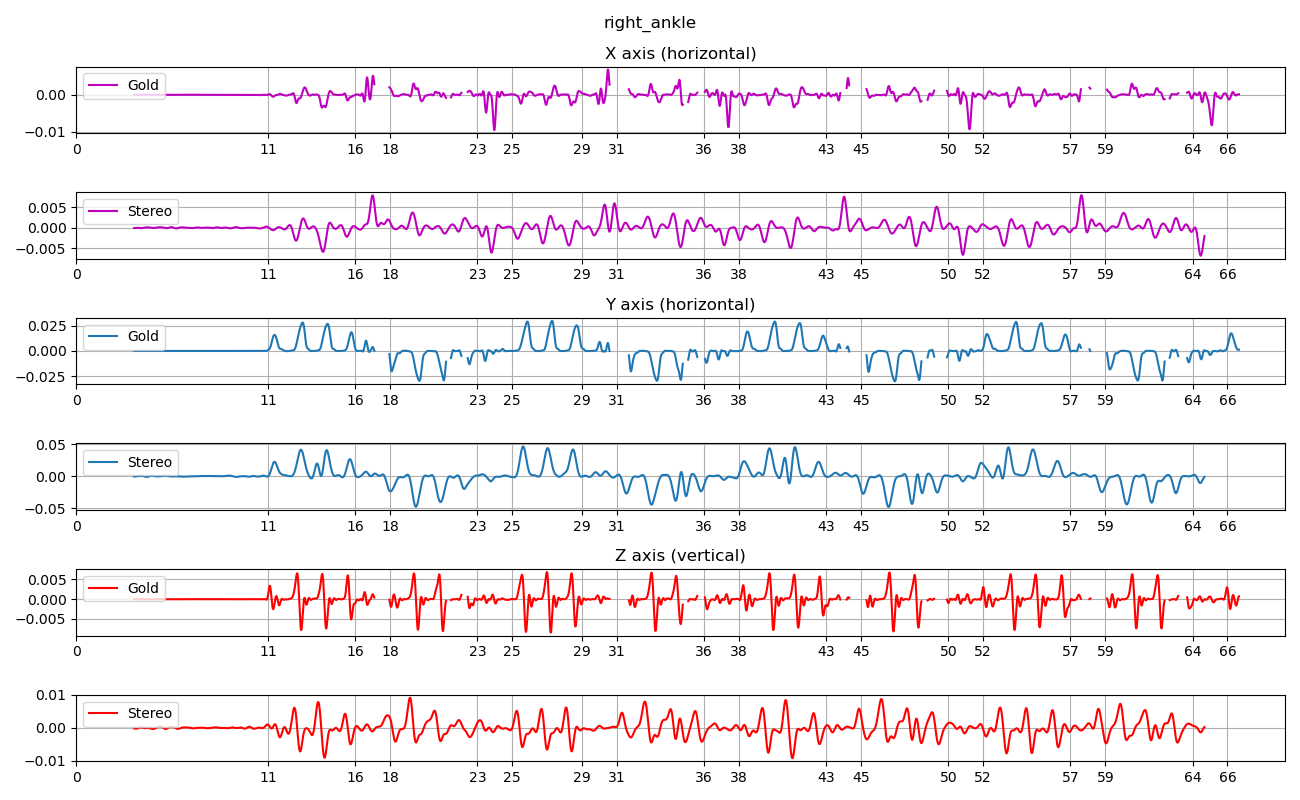

In [ ]:
# perform filtering, visualize results as a comparison between Qualisys and Stereo
from scipy.signal import butter, filtfilt

keypoints_3d_filtered = loaded_data["keypoints_3d"]


keypoint_name = "right_ankle"
contra_keypoint_name = "left_ankle"

# Qualisys
qualisys_idx = list(qualisys_labels).index(keypoint_name)
qualisys_data = filter_data(qualisys_data, 100, "lowpass", [7], 4, 0.25)

Qd = qualisys_data[qualisys_idx, 0, :] / 1000
Qx = qualisys_data[qualisys_idx, 2, :] / 1000
Qy = qualisys_data[qualisys_idx, 1, :] / 1000


# stereo
stereo_idx = kpt_labels.index(keypoint_name)
keypoints_3d_filtered = filter_data(keypoints_3d, 60, "lowpass", [2], 4, 0.25)

#TODO: try to figure out why bandpass makes it broken
# keypoints_3d_filtered[:, :2, :] = filter_data(copy.deepcopy(keypoints_3d_filtered), 60, "lowpass", [2], 4, 0.25)[:, :2, :]
# keypoints_3d_filtered[:, 2, :] = filter_data(copy.deepcopy(keypoints_3d_filtered), 60, "bandpass", [0.2, 2], 4, 0.25)[:, 2, :]


shift = 225
Sd = keypoints_3d_filtered[stereo_idx, 0, shift:]
Sx = keypoints_3d_filtered[stereo_idx, 1, shift:]
Sy = keypoints_3d_filtered[stereo_idx, 2, shift:]


## plot
tQ = np.linspace(0, len(Qd) / 100, len(Qd))
tS = np.linspace(0, len(Sx) / 60, len(Sx))
xticks = np.array([0, 11, 16, 18, 23, 25, 29, 31, 36, 38, 43, 45, 50, 52, 57, 59, 64, 66])  # manual annotation
plt.close("all")
fig, axs = plt.subplots(6, 1, figsize=(13, 8))


## Horizontal ax 1-------------------------------------------------------
# axs[0].plot(tQ, Qy, "m", label="Gold")
axs[0].plot(tQ[1:],np.diff(Qy),'m',label = 'Gold')
# axs[1].plot(tS, Sx, "m", label="Stereo")
axs[1].plot(tS[1:],np.diff(Sx),'m',label='Stereo')
# axs[1].plot(tS,keypoints_3d[stereo_idx,1,shift:],"g--",alpha=0.5,label="raw")

## Horizontal ax 2-------------------------------------------------------
# axs[2].plot(tQ, Qd, label="Gold")
axs[2].plot(tQ[1:],np.diff(Qd),label='Gold')
# axs[3].plot(tS, Sd, label="Stereo")
axs[3].plot(tS[1:],np.diff(Sd),label='Stereo')
# axs[3].plot(tS,keypoints_3d[stereo_idx,0,shift:],"g--",alpha=0.5,label="raw")

## Vertical ax ----------------------------------------------------------
# axs[4].plot(tQ, Qx, "r", label="Gold")
axs[4].plot(tQ[1:],np.diff(Qx),'r',label = 'Gold')
# axs[5].plot(tS, Sy, "r", label="Stereo")
axs[5].plot(tS[1:],np.diff(Sy),'r',label='Stereo')
# axs[5].plot(tS,keypoints_3d[stereo_idx,2,shift:],"g--",alpha=0.5,label="raw")


plt.suptitle(keypoint_name)
axs[0].set_title("X axis (horizontal)")
axs[2].set_title("Y axis (horizontal)")
axs[4].set_title("Z axis (vertical)")
for ax in axs:
    ax.legend(loc="upper left")
    ax.set_xlim([min(xticks), max(xticks)])
    ax.set_xticks(xticks - 3.3, xticks)
    ax.grid()

plt.tight_layout()

In [43]:
save_path = "stereo_videos\\validation_test\\43916681.npz"

with open(save_path, "w") as f:
    np.savez(
        save_path,
        keypoints_2d=keypoints_2d,
        confidence_2d=confidence_2d,
        color=color,
        kpt_labels=kpt_labels,
        keypoints_3d=keypoints_3d,
        keypoints_3d_filtered=keypoints_3d_filtered,
        R = R,
        t = t
    )

print(f"Saved 3D keypoints to {save_path}")

Saved 3D keypoints to stereo_videos\validation_test\43916681.npz


# WP

## PLY

In [ ]:
import open3d as o3d

In [ ]:
print(f"keypoints_3d shape: {keypoints_3d.shape} (kpt * dims * frames)")
print(f"color shape:        {color.shape} (frames * kpt * rgb)")

In [ ]:
keypoints_3d_one_frame = keypoints_3d[:,:,0] #(kpt * dims * frames)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(keypoints_3d_one_frame)
pcd.colors = o3d.utility.Vector3dVector(color[0,:,:]/255.0)
o3d.io.write_point_cloud("./data.ply", pcd, write_ascii=True)
o3d.visualization.draw_geometries([pcd])


## Spectral anal + filt

In [ ]:
keypoints_3d = loaded_data["keypoints_3d_wf"]## TODO: remname keypoints_3d_wf to keypoints_3d
Sy = keypoints_3d[stereo_idx, 2, shift:]

nans = np.isnan(Sy)

# if there are nans, interpolate the missing values for subsequent filtering
if np.any(nans):
    valid_indices = ~nans
    Sy[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(valid_indices), Sy[valid_indices])

plt.close('all')
plt.figure(figsize=(15,2))
fft_Sy = fft(Sy)
N = len(fft_Sy)
n = np.arange(N)
freq = n / (N / 60)

PSD = fft_Sy * np.conj(fft_Sy) / N
PSD = np.array(PSD)
limit = 0.2
indices =  PSD < limit # indices 
PSDClean = PSD*indices 

# indices[0] = False

fhat = indices * fft_Sy
ffilt = np.fft.ifft(fhat)

b, a = butter(N=4, Wn=[2,3], btype="bandpass", analog=False, fs=60)
Sy_filt = filtfilt(b, a, ffilt)

plt.close('all')
fig, axs = plt.subplots(2, 1, figsize=(13, 4))
axs[0].plot(freq,PSD)
axs[0].set_xlim([0,6])
axs[0].set_ylim([0,5])
axs[0].hlines(limit,0,6, color='r', linestyles='dashed')


axs[1].plot(freq,PSDClean)
axs[1].set_xlim([0,6])

plt.show()



plt.figure(figsize=(15,4))
plt.plot(ffilt,'m')
plt.plot(Sy+.5,'b')
plt.plot(Sy_filt-.5,'r')

plt.show()

In [ ]:
indices[:10]

In [ ]:
plt.close('all')
plt.figure(figsize=(13,6))

bandpass = [0.2, 15]
# orders = [1, 4,7, 8]
# band_mins = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
band_maxs = [4,5,8,10,15,20]
values = band_maxs
for idx, value in enumerate(values,1):
    b, a = butter(6, [0.2, value], fs=60, btype="band", analog=False)
    result = filtfilt(b,a,ry)
    plt.subplot(len(values),1,idx)
    plt.plot(result, label=str(value))
    plt.hlines(0,0,len(result),'r')
    plt.legend()
    

In [ ]:
# keypoints_over_time.transpose(1,2,0).shape, 
keypoints_3d.transpose(1,2,0).shape

In [ ]:
bandpass = [0.2, 4]
b, a = butter(6, bandpass, fs=60, btype="band", analog=False)

test = []

for kpt_idx, kpt in enumerate(raw_keypoints.transpose(1,2,0)):
    # fx = filtfilt(b, a, kpt[0,:])
    # fy = filtfilt(b, a, kpt[1,:])
    sx = np.multiply(kpt[0,:], scale)
    # fy = kpt[1,:]
    fy = filtfilt(b,a,kpt[1,:])
    sfy = np.multiply(fy, scale)

    depth = keypoints_3d.transpose(1,2,0)[kpt_idx,0,:]
    # print(fx.shape, fy.shape, depth.shape)
    test.append(np.stack((depth,sx,sfy)))
test= np.array(test)
print(test.shape)
type(test)
    

In [ ]:
faszom = "stereo_videos\\validation_test\\test.npz"
with open(faszom, "w") as f:
    np.savez(faszom, raw_keypoints = raw_keypoints, keypoints_2d=keypoints_2d, keypoints_3d=keypoints_3d, kpt_labels=kpt_labels, scale=scale, test = test)

print(f"Saved 3D keypoints to {faszom}")

# Gait analysis

## Step detection

In [45]:
## load STEREO data
npz_load_path = "stereo_videos\\validation_test\\43916681.npz"
loaded_data = np.load(npz_load_path)

keypoints_2d = loaded_data["keypoints_2d"]
confidence_2d = loaded_data["confidence_2d"]
color = loaded_data["color"]
keypoints_3d = loaded_data["keypoints_3d"]
keypoints_3d_filtered = loaded_data["keypoints_3d_filtered"]

kpt_labels = list(loaded_data["kpt_labels"])
R = loaded_data["R"]
t = loaded_data["t"]

print(f"loaded data : {npz_load_path}\nwith keys and shapes:")
[f"{key}:    {loaded_data[key].shape}" for key in list(loaded_data.keys())]

loaded data : stereo_videos\validation_test\43916681.npz
with keys and shapes:


['keypoints_2d:    (3908, 26, 2)',
 'confidence_2d:    (3908, 26)',
 'color:    (3908, 26, 3)',
 'kpt_labels:    (26,)',
 'keypoints_3d:    (26, 3, 3908)',
 'keypoints_3d_filtered:    (26, 3, 3908)',
 'R:    (3, 3)',
 't:    (3, 1)']

In [ ]:
gait_events, _ = step_detection(keypoints_3d_filtered,kpt_labels,properties)